In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
WHO_predict_roc = np.load("../output/WHO_predict/ROC.npy", allow_pickle=True)
WHO_predict_acc = pd.read_csv("../output/WHO_predict/accuracy.csv", index_col=0)

In [3]:
def lineplot(data, x=None, y=None, hue=None, xticklabels=None, output_path: str = None, figsize: tuple = (24, 12)):
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=figsize)

    ax = sns.lineplot(data=data, x=x, y=y, hue=hue)
    ax = sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', color='red')

    plt.legend(loc='lower right')
    plt.grid(False)

    if x:
        plt.xlabel(x)
    if y:
        plt.ylabel(y)
    if xticklabels:
        ax.set_xticklabels(labels=xticklabels)

    if output_path:
        plt.savefig(output_path, bbox_inches="tight")
    plt.show()

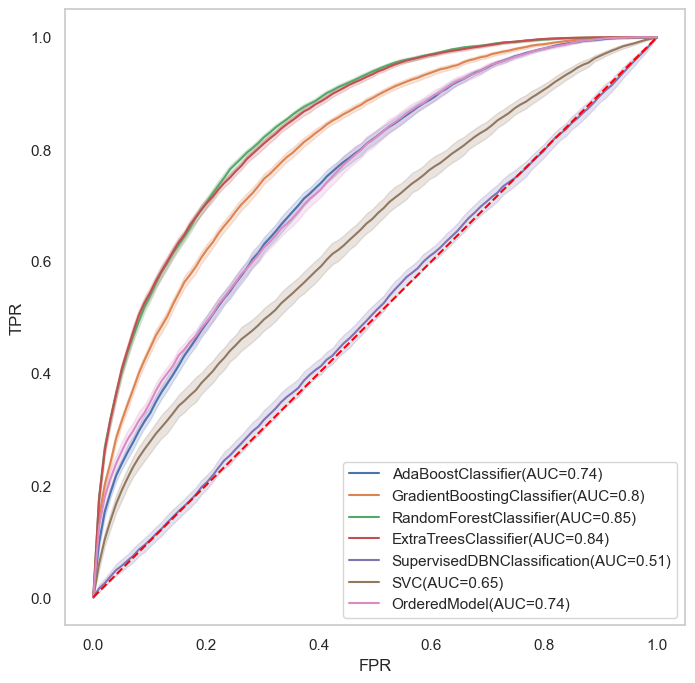

In [4]:
def plot(roc, output_dir=None):
    methods_result = roc.item()

    _rocs = pd.DataFrame()
    for method_name in methods_result.keys():
        _xs, _ys = methods_result[method_name][0], methods_result[method_name][1]

        tprs = []
        mean_fpr = np.linspace(0, 1, 100)
        for i in range(len(_xs)):
            _x, _y = _xs[i], _ys[i]
            interp_tpr = np.interp(mean_fpr, _x, _y)
            interp_tpr[0], interp_tpr[-1] = 0.0, 1
            _tprs = interp_tpr.tolist()
            tprs.extend(_tprs)

        _df = pd.DataFrame({
            'FPR': mean_fpr.tolist() * len(_xs), 'TPR': tprs,
            'method': '{}(AUC={})'.format(method_name, round(np.mean(methods_result[method_name][2]), 2))
        })
        _rocs = pd.concat([_rocs, _df])
    _rocs.reset_index(drop=True, inplace=True)

    lineplot(
        _rocs,
        x='FPR',
        y='TPR',
        hue='method',
        output_path='{}/ROC.pdf'.format(output_dir) if output_dir else None,
        figsize=(8, 8)
    )

plot(WHO_predict_roc, '../output/WHO_predict')

In [5]:
def get_comprehensive_comparison(acc, roc):
    acc_result = pd.DataFrame(acc.mean(), columns=["Accuracy(%)"])
    acc_result = (round(acc_result * 100, 2)).astype(str)
    acc_result["Accuracy(%)"] += '±' + (round(acc.std() * 100, 2)).astype(str)

    _roc = roc.item()
    _roc_auc = [roc.item()[key][2] for key in _roc.keys()]
    _roc_auc = pd.DataFrame(_roc_auc, index=_roc.keys())
    roc_auc_result = pd.DataFrame(_roc_auc.mean(axis=1), columns=["ROC-AUC"])
    roc_auc_result = (round(roc_auc_result, 2)).astype(str)
    roc_auc_result["ROC-AUC"] += '±' + (round(_roc_auc.std(axis=1), 2)).astype(str)

    comprehensive_result = pd.concat([acc_result, roc_auc_result], axis=1)
    return comprehensive_result

In [6]:
comprehensive_result = get_comprehensive_comparison(WHO_predict_acc, WHO_predict_roc)
comprehensive_result.to_csv('../output/WHO_predict/comprehensive_comparison.csv')
comprehensive_result

,Accuracy(%),ROC-AUC
AdaBoostClassifier,42.1±4.11,0.74±0.02
GradientBoostingClassifier,48.97±2.7,0.8±0.01
RandomForestClassifier,54.82±2.72,0.85±0.01
ExtraTreesClassifier,55.51±2.94,0.84±0.01
SupervisedDBNClassification,20.53±3.7,0.51±0.03
SVC,30.62±4.37,0.65±0.05
OrderedModel,40.86±4.03,0.74±0.03


In [7]:
after_treatment_data = pd.read_excel("../raw_data/after_treatment.xlsx", index_col=0, header=[0])
after_treatment_data = after_treatment_data["WHO classify (affected side) after treatment"].value_counts()

after_treatment_data.max() / after_treatment_data.sum()

0.25833333333333336